In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

from importlib import reload

import sys
sys.path.append("../helpers")
import binfrac, norm, imf

fs = 24
style_params = {
    'font.family': 'serif',
    'text.usetex': False,
    'figure.figsize': (12, 8),
    'axes.titlesize': 24,
    'legend.title_fontsize': 18,
    'legend.fontsize': 16,
    'axes.labelsize': 24,
    'xtick.labelsize': 21,
    'ytick.labelsize': 21,
    'axes.linewidth': 1.1,
    'xtick.major.size': 7,
    'xtick.minor.size': 4,
    'ytick.major.size': 7,
    'ytick.minor.size': 4,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
}

plt.rcParams.update(style_params)

%config InlineBackend.figure_format = 'retina'

# Binary fraction

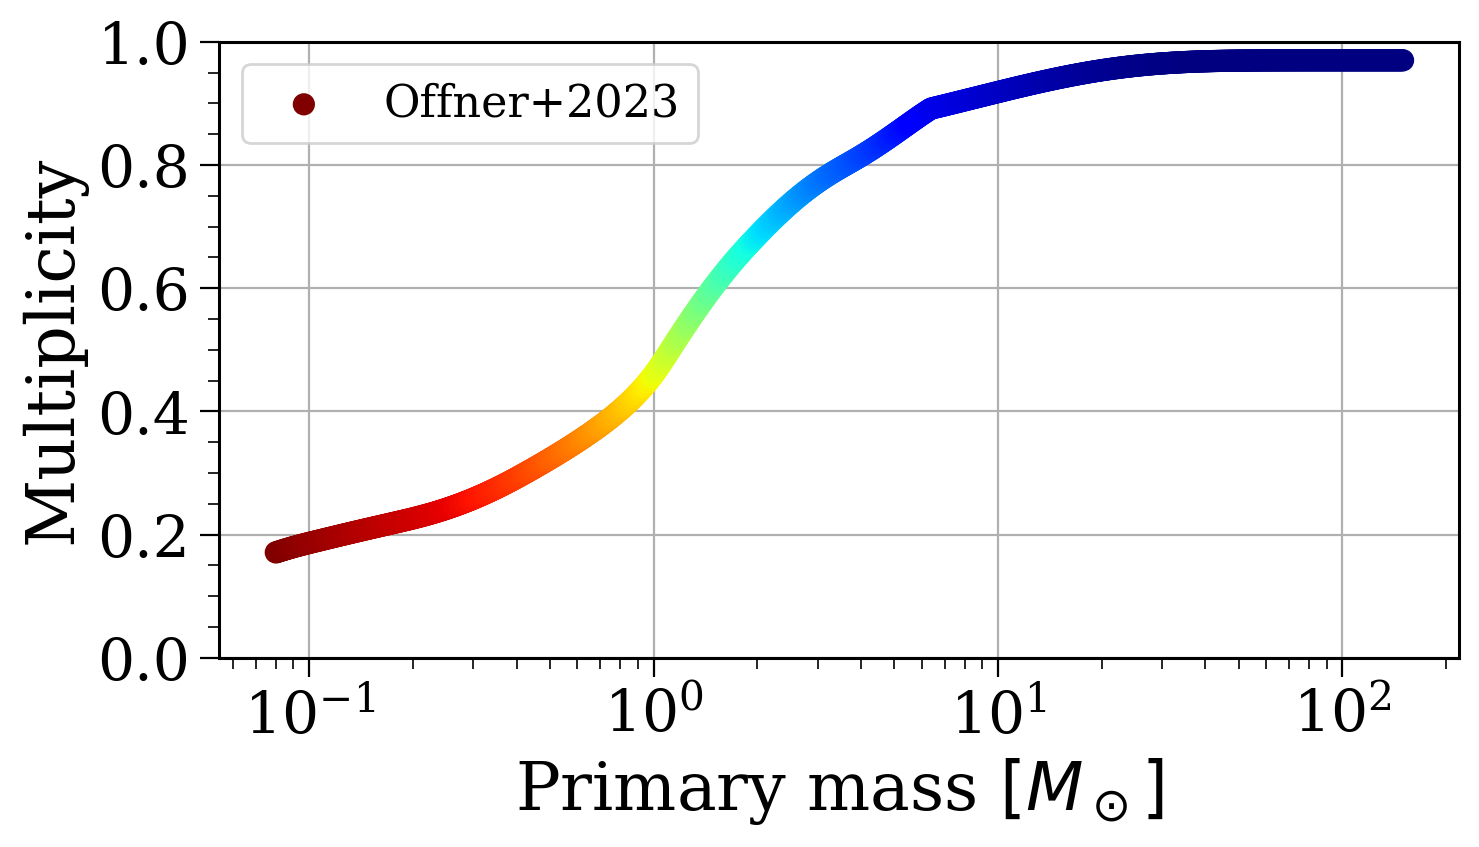

In [27]:
reload(binfrac)
mass_range = np.geomspace(0.08, 150, 1000)

bf = binfrac.offner_multiplicity(mass_range)

fig, ax = plt.subplots(figsize=(8, 4))

ax.scatter(mass_range, bf, c=bf, lw=2, cmap="jet_r", label="Offner+2023")
ax.legend()

ax.set(
    ylim=(0, 1),
    xscale="log",
    xlabel=r"Primary mass $[M_\odot]$",
    ylabel=r"Multiplicity",
)

# add a grid in the background with zorder below scatter points
ax.grid(True)
ax.set_axisbelow(True)

plt.show()

# Initial mass function

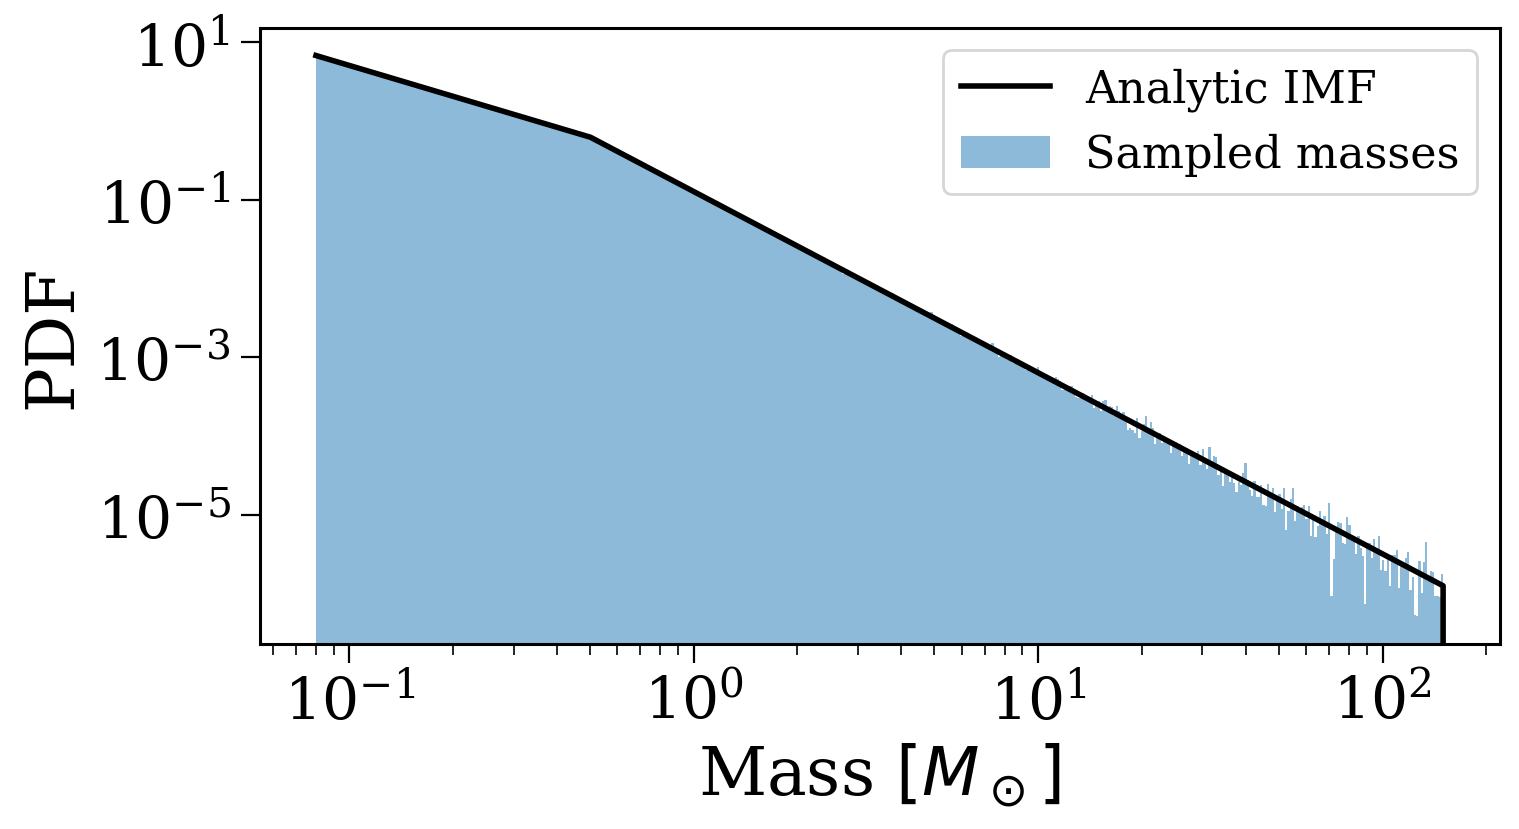

In [38]:
reload(imf)

mass_range = np.geomspace(0.08, 150, 10000)
    
sample = np.random.uniform(0, 1.0, size=1000000)
sampled_masses = imf.inverse_CDF_IMF(sample)

sampled_secondaries = np.random.uniform(0, 1.0, size=len(sampled_masses)) * sampled_masses

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(mass_range, imf.IMF(mass_range), color='k', lw=2, label="Analytic IMF")
ax.hist(sampled_masses, bins=np.geomspace(0.08, 150, 500), density=True, alpha=0.5, label='Sampled masses')

ax.set(
    xscale="log",
    yscale="log",
    xlabel=r"Mass $[M_\odot]$",
    ylabel=r"PDF",
)

ax.legend()
plt.show()

# Sampling fraction

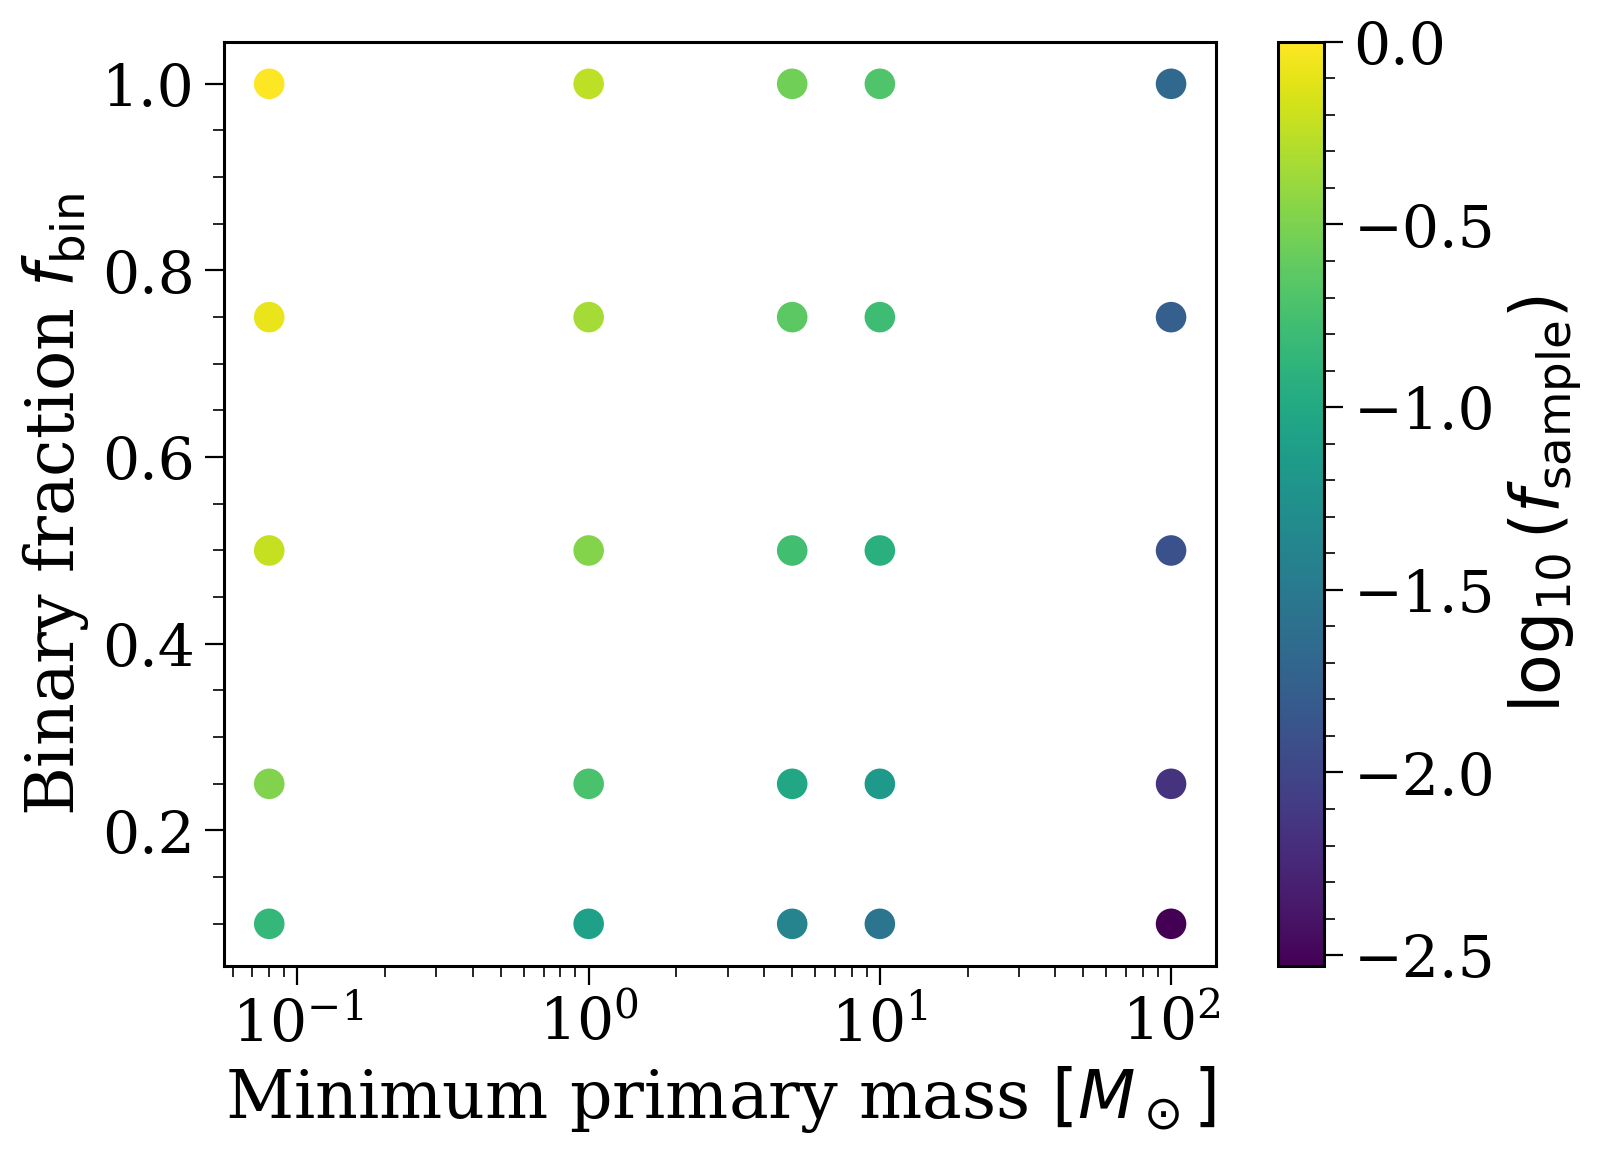

In [131]:
f_bins = [0.1, 0.25, 0.5, 0.75, 1.0]
m1_mins = [0.08, 1.0, 5.0, 10.0, 100.0]

f_samples = np.zeros((len(f_bins), len(m1_mins)))

for i, f_bin in enumerate(f_bins):
    for j, m1_min in enumerate(m1_mins):
        f_sample, avg_mass_sample, avg_mass_full = norm.calculate_f_sample(
            m1_min=m1_min, m2_min=0.0, f_bin=f_bin
        )
        f_samples[i, j] = f_sample

fig, ax = plt.subplots(figsize=(8, 6))

M, F = np.meshgrid(m1_mins, f_bins)
scatter = plt.scatter(M.flatten(), F.flatten(), c=np.log10(f_samples.flatten()), cmap="viridis", s=100)
plt.colorbar(scatter, label=r"$\log_{10}(f_\mathrm{sample})$")
plt.xscale("log")
plt.xlabel(r"Minimum primary mass $[M_\odot]$")
plt.ylabel(r"Binary fraction $f_\mathrm{bin}$")
plt.show()

In [ ]:
f_sample, avg_mass_sample, avg_mass_full = norm.calculate_f_sample(
    m1_min=5, m2_min=0.0, f_bin=binfrac.offner_at_least_binary_fraction
)
print(f"f_sample: {f_sample:.2f}, avg_mass_sample: {avg_mass_sample:.2f} Msun , avg_mass_full: {avg_mass_full:.2f} Msun")

f_sample: 0.31, avg_mass_sample: 0.23 Msun, avg_mass_full: 0.76 Msun
